<a href="https://colab.research.google.com/github/HoaiPhuong-Nguyen/AIHC5020/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google-cloud-storage

In [ ]:
# Problem 1
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials
import pandas as pd
from io import StringIO

storage_client = storage.Client(credentials=AnonymousCredentials())
bucket = storage_client.bucket("cloud-samples-data")

def load_csv_blob(blob_name, bucket, column_names = []):
  blob = bucket.blob(blob_name)
  data = blob.download_as_text()
  if column_names:
      df = pd.read_csv(StringIO(data), header=None, names=column_names)
  else:
      df = pd.read_csv(StringIO(data), header=None)
  return df

In [ ]:
for blob in bucket.list_blobs(prefix="ml-engine/"):
    print(blob.name)

Streaming output truncated to the last 5000 lines.
ml-engine/fake_imagenet_split/train-08104-of-09216
ml-engine/fake_imagenet_split/train-08105-of-09216
ml-engine/fake_imagenet_split/train-08106-of-09216
ml-engine/fake_imagenet_split/train-08107-of-09216
ml-engine/fake_imagenet_split/train-08108-of-09216
ml-engine/fake_imagenet_split/train-08109-of-09216
ml-engine/fake_imagenet_split/train-08110-of-09216
ml-engine/fake_imagenet_split/train-08111-of-09216
ml-engine/fake_imagenet_split/train-08112-of-09216
ml-engine/fake_imagenet_split/train-08113-of-09216
ml-engine/fake_imagenet_split/train-08114-of-09216
ml-engine/fake_imagenet_split/train-08115-of-09216
ml-engine/fake_imagenet_split/train-08116-of-09216
ml-engine/fake_imagenet_split/train-08117-of-09216
ml-engine/fake_imagenet_split/train-08118-of-09216
ml-engine/fake_imagenet_split/train-08119-of-09216
ml-engine/fake_imagenet_split/train-08120-of-09216
ml-engine/fake_imagenet_split/train-08121-of-09216
ml-engine/fake_imagenet_split/t

In [ ]:
# Test Problem 1
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

df = load_csv_blob("ml-engine/sklearn/census_data/adult.data", bucket, COLUMN_NAMES)
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country income_bracket  
0          2174             0              40   United-States

In [1]:
from google.colab import auth
auth.authenticate_user()

In [4]:
#Problem 2

from google.cloud import bigquery

project_id = "<your_project_id_here>"
client = bigquery.Client(project=project_id)

query = """
SELECT
  date,
  new_confirmed,
  new_deceased
FROM
  `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
  country_name = 'Mexico'
  AND EXTRACT(YEAR FROM date) = 2021
ORDER BY
  date ASC
"""

query_job = client.query(query)
df = query_job.to_dataframe()

print("Number of rows:", len(df))
df.head()

Number of rows: 911770


,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


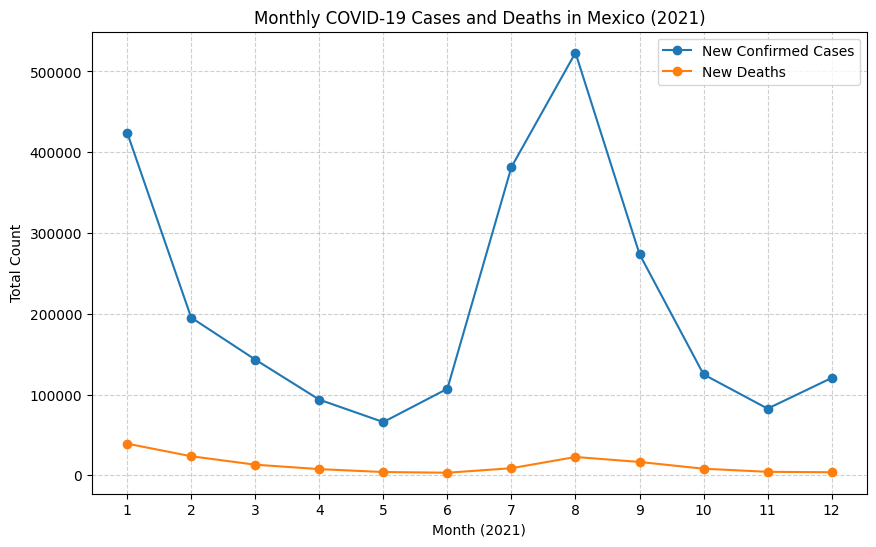

In [6]:
# Problem 3

df['month'] = df['date'].apply(lambda dt: dt.month)
monthly_totals = df.groupby('month')[['new_confirmed', 'new_deceased']].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(monthly_totals['month'], monthly_totals['new_confirmed'], marker='o', label='New Confirmed Cases')
plt.plot(monthly_totals['month'], monthly_totals['new_deceased'], marker='o', label='New Deaths')

plt.title('Monthly COVID-19 Cases and Deaths in Mexico (2021)')
plt.xlabel('Month (2021)')
plt.ylabel('Total Count')
plt.xticks(range(1,13))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()